# 1. Title and purpose

This notebook is the post-ETL transformation and serving layer for the **Argentina Portfolio Risk Intelligence Pipeline**.

The ETL notebook is assumed to have already ingested Argentine market data and uploaded raw and processed tables into BigQuery. This notebook focuses on the right-hand side of the data engineering lifecycle: transforming processed data into analytics-ready portfolio outputs and serving tables.

## What this notebook does
- Connects to BigQuery and validates that processed inputs exist.
- Reads processed market data that was generated during the ETL stage.
- Documents how dbt Core fits into the transformation layer.
- Computes portfolio risk-return metrics for a user-defined Argentine equity portfolio.
- Runs Monte Carlo simulations to estimate forward-looking portfolio outcomes.
- Produces decision-support outputs such as VaR, CVaR, probability of loss, contributions, and classification labels.
- Uploads dashboard-ready analytics tables back into BigQuery.
- Generates a data dictionary and a lineage diagram suitable for the assignment deliverables.

## Output scope
The notebook produces Monte Carlo simulation tables, risk metrics, serving-layer tables, and supporting documentation artifacts that can be used in a dashboard, report, or architecture presentation.

# 2. Imports and configuration

This section imports the core Python packages used for warehouse access, analytics, simulation, and chart generation.

The placeholders below should be updated before execution:
- `PROJECT_ID`
- dataset names if your naming differs from the defaults
- portfolio tickers and weights if you want a different investment scenario

In [6]:
import os
import uuid
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timezone
from google.cloud import bigquery

PROJECT_ID = "bigdata-financeargentina"
LOCATION = "US"

RAW_DATASET = "raw_market"
PROCESSED_DATASET = "processed_market"
ANALYTICS_DATASET = "analytics_market"

RUN_ID = str(uuid.uuid4())
PORTFOLIO_ID = "argentina_demo_portfolio"
INGESTION_TIMESTAMP = datetime.now(timezone.utc)

USER_PORTFOLIO = {
    "GGAL.BA": 0.25,
    "YPFD.BA": 0.25,
    "PAMP.BA": 0.20,
    "BMA.BA": 0.15,
    "CEPU.BA": 0.15
}

INITIAL_PORTFOLIO_VALUE = 10000
NUM_SIMULATIONS = 10000
SIMULATION_DAYS = 252
RANDOM_SEED = 42

# 3. BigQuery connection

This notebook uses the BigQuery Python client and relies on Google Cloud authentication outside the notebook.

## Authentication notes
- For local development, use Application Default Credentials with `gcloud auth application-default login`.
- For service-account authentication, set the `GOOGLE_APPLICATION_CREDENTIALS` environment variable to the JSON key path.
- Do not hardcode or commit credentials into the repository.

If the notebook fails at client creation, verify that your Google account or service account has permission to read from the processed datasets and write into the analytics dataset.

In [7]:
client = bigquery.Client(project=PROJECT_ID, location=LOCATION)


def table_ref(dataset, table):
    return f"{PROJECT_ID}.{dataset}.{table}"

# 4. Helper functions

The helper functions below keep the notebook easier to read and more robust for academic evaluation.

They cover four concerns:
- warehouse access and table uploads
- defensive numeric utilities
- finance metric calculations
- portfolio input validation

In [8]:
def run_query(sql: str) -> pd.DataFrame:
    """Run a SQL query in BigQuery and return a pandas DataFrame."""
    job = client.query(sql)
    return job.result().to_dataframe(create_bqstorage_client=False)


def table_exists(dataset: str, table: str) -> bool:
    """Return True if a BigQuery table exists, otherwise False."""
    try:
        client.get_table(table_ref(dataset, table))
        return True
    except Exception:
        return False


def delete_existing_run_rows(dataset: str, table: str, run_ids) -> None:
    """Delete existing rows for the same run_id values before re-appending a run."""
    if not run_ids or not table_exists(dataset, table):
        return

    delete_sql = f"""
    DELETE FROM `{table_ref(dataset, table)}`
    WHERE run_id IN UNNEST(@run_ids)
    """
    job_config = bigquery.QueryJobConfig(
        query_parameters=[
            bigquery.ArrayQueryParameter("run_ids", "STRING", list(run_ids))
        ]
    )
    client.query(delete_sql, job_config=job_config).result()
    print(f"Removed existing rows for {len(run_ids)} run_id value(s) from {table_ref(dataset, table)}")


def load_dataframe_to_bq(df, dataset, table, write_disposition="WRITE_TRUNCATE"):
    """Upload a pandas DataFrame to BigQuery with a configurable write disposition."""
    if df is None or df.empty:
        raise ValueError(f"Refusing to upload an empty DataFrame to {dataset}.{table}")

    target_table = table_ref(dataset, table)
    job_config = bigquery.LoadJobConfig(write_disposition=write_disposition)

    # Allow additive schema changes on append runs for evolving analytics tables.
    if write_disposition == "WRITE_APPEND":
        job_config.schema_update_options = [
            bigquery.SchemaUpdateOption.ALLOW_FIELD_ADDITION,
            bigquery.SchemaUpdateOption.ALLOW_FIELD_RELAXATION,
        ]

        if "run_id" in df.columns:
            run_ids = (
                df["run_id"]
                .dropna()
                .astype(str)
                .unique()
                .tolist()
            )
            delete_existing_run_rows(dataset, table, run_ids)

    job = client.load_table_from_dataframe(df, target_table, job_config=job_config)
    job.result()
    print(f"Uploaded {len(df):,} rows to {target_table} with {write_disposition}")


def annualize_return(mean_daily_return):
    """Convert average daily return to annualized return using 252 trading days."""
    if pd.isna(mean_daily_return):
        return np.nan
    return (1 + mean_daily_return) ** 252 - 1


def annualize_volatility(daily_std):
    """Convert daily standard deviation to annualized volatility."""
    if pd.isna(daily_std):
        return np.nan
    return daily_std * np.sqrt(252)


def calculate_max_drawdown(return_series):
    """Calculate the maximum drawdown from a series of returns."""
    if return_series is None:
        return np.nan

    clean_returns = pd.Series(return_series).dropna()
    if clean_returns.empty:
        return np.nan

    cumulative = (1 + clean_returns).cumprod()
    running_peak = cumulative.cummax()
    drawdown = cumulative / running_peak - 1
    return drawdown.min()


def validate_portfolio_weights(user_portfolio):
    """Validate that portfolio weights are non-negative and sum to 1."""
    if not user_portfolio:
        raise ValueError("USER_PORTFOLIO is empty. Please provide at least one ticker and weight.")

    weights = pd.Series(user_portfolio, dtype="float64")

    if (weights < 0).any():
        negative_tickers = weights[weights < 0].index.tolist()
        raise ValueError(f"Negative weights are not allowed: {negative_tickers}")

    total_weight = weights.sum()
    if not np.isclose(total_weight, 1.0, atol=1e-8):
        raise ValueError(f"Portfolio weights must sum to 1. Current sum: {total_weight:.8f}")

    return weights


def safe_divide(numerator, denominator):
    """Safely divide two numbers and return NaN when denominator is zero or null."""
    if denominator is None or pd.isna(denominator) or np.isclose(denominator, 0):
        return np.nan
    return numerator / denominator

# 5. Validate BigQuery input tables

Before analytics begin, the notebook validates that the required processed tables from the ETL stage are already present in BigQuery.

This is an important serving-layer control because it prevents silent failures later in the workflow and gives a clear checkpoint between ETL and transformation/analytics.

In [9]:
required_tables = [
    ("processed_market", "asset_returns"),
    ("processed_market", "factor_returns"),
    ("processed_market", "stock_metrics"),
    ("processed_market", "beta_metrics"),
    ("processed_market", "correlation_matrix_long")
]

missing_tables = []

for dataset, table in required_tables:
    exists = table_exists(dataset, table)
    status = "OK" if exists else "MISSING"
    print(f"[{status}] {table_ref(dataset, table)}")
    if not exists:
        missing_tables.append(table_ref(dataset, table))

if missing_tables:
    raise FileNotFoundError(
        "The following required BigQuery tables are missing from the ETL stage:\n"
        + "\n".join(missing_tables)
    )

[OK] bigdata-financeargentina.processed_market.asset_returns
[OK] bigdata-financeargentina.processed_market.factor_returns
[OK] bigdata-financeargentina.processed_market.stock_metrics
[OK] bigdata-financeargentina.processed_market.beta_metrics
[OK] bigdata-financeargentina.processed_market.correlation_matrix_long


# 6. Load processed tables from BigQuery

This section reads the processed-layer tables from BigQuery into pandas DataFrames.

Data-quality handling included here:
- parse `date` fields as datetime
- cast ticker identifiers to string
- coerce return fields to numeric
- remove exact duplicates defensively
- sort data for stable downstream calculations

In [10]:
asset_returns = run_query(f"SELECT * FROM `{table_ref(PROCESSED_DATASET, 'asset_returns')}`")
factor_returns = run_query(f"SELECT * FROM `{table_ref(PROCESSED_DATASET, 'factor_returns')}`")
stock_metrics = run_query(f"SELECT * FROM `{table_ref(PROCESSED_DATASET, 'stock_metrics')}`")
beta_metrics = run_query(f"SELECT * FROM `{table_ref(PROCESSED_DATASET, 'beta_metrics')}`")
correlation_matrix_long = run_query(f"SELECT * FROM `{table_ref(PROCESSED_DATASET, 'correlation_matrix_long')}`")

for df_name, df in {
    "asset_returns": asset_returns,
    "factor_returns": factor_returns,
    "stock_metrics": stock_metrics,
    "beta_metrics": beta_metrics,
    "correlation_matrix_long": correlation_matrix_long,
}.items():
    if df.empty:
        raise ValueError(f"{df_name} was loaded from BigQuery but is empty.")

if "date" in asset_returns.columns:
    asset_returns["date"] = pd.to_datetime(asset_returns["date"], utc=False, errors="coerce")
if "date" in factor_returns.columns:
    factor_returns["date"] = pd.to_datetime(factor_returns["date"], utc=False, errors="coerce")

for col in ["ticker", "ticker_1", "ticker_2"]:
    if col in asset_returns.columns:
        asset_returns[col] = asset_returns[col].astype(str)
    if col in stock_metrics.columns:
        stock_metrics[col] = stock_metrics[col].astype(str)
    if col in beta_metrics.columns:
        beta_metrics[col] = beta_metrics[col].astype(str)
    if col in correlation_matrix_long.columns:
        correlation_matrix_long[col] = correlation_matrix_long[col].astype(str)

for numeric_col in ["log_return", "simple_return", "usd_adjusted_return", "excess_return", "risk_free_daily"]:
    if numeric_col in asset_returns.columns:
        asset_returns[numeric_col] = pd.to_numeric(asset_returns[numeric_col], errors="coerce")

for numeric_col in ["factor_return", "risk_free_daily", "merval_return", "eem_return", "fx_return"]:
    if numeric_col in factor_returns.columns:
        factor_returns[numeric_col] = pd.to_numeric(factor_returns[numeric_col], errors="coerce")

asset_returns = asset_returns.drop_duplicates().sort_values([c for c in ["date", "ticker"] if c in asset_returns.columns]).reset_index(drop=True)
factor_returns = factor_returns.drop_duplicates().sort_values([c for c in ["date"] if c in factor_returns.columns]).reset_index(drop=True)
stock_metrics = stock_metrics.drop_duplicates().reset_index(drop=True)
beta_metrics = beta_metrics.drop_duplicates().reset_index(drop=True)
correlation_matrix_long = correlation_matrix_long.drop_duplicates().reset_index(drop=True)

print("Loaded tables successfully:")
print(f"- asset_returns: {asset_returns.shape}")
print(f"- factor_returns: {factor_returns.shape}")
print(f"- stock_metrics: {stock_metrics.shape}")
print(f"- beta_metrics: {beta_metrics.shape}")
print(f"- correlation_matrix_long: {correlation_matrix_long.shape}")

Loaded tables successfully:
- asset_returns: (9745, 14)
- factor_returns: (10057, 4)
- stock_metrics: (5, 14)
- beta_metrics: (5, 3)
- correlation_matrix_long: (25, 3)


# 7. Build returns wide table

Portfolio analytics and Monte Carlo simulation are easier to compute using a wide return matrix with:
- one row per date
- one column per ticker
- daily `log_return` as the value

`pivot_table` is intentionally used instead of `pivot` because duplicate `date` and `ticker` pairs can happen in data lake and warehouse pipelines.

In [11]:
required_asset_columns = {"date", "ticker", "log_return"}
missing_asset_columns = required_asset_columns - set(asset_returns.columns)
if missing_asset_columns:
    raise ValueError(f"asset_returns is missing required columns: {sorted(missing_asset_columns)}")

returns_wide = asset_returns.pivot_table(
    index="date",
    columns="ticker",
    values="log_return",
    aggfunc="mean"
).sort_index()

# Remove columns that contain no usable return history at all.
returns_wide = returns_wide.dropna(axis=1, how="all")

if returns_wide.empty:
    raise ValueError("returns_wide is empty after pivoting. Check processed_market.asset_returns.")

min_required_observations = max(30, SIMULATION_DAYS // 4)
observation_counts = returns_wide.notna().sum().sort_values(ascending=False)
valid_columns = observation_counts[observation_counts >= min_required_observations].index.tolist()
returns_wide = returns_wide[valid_columns]

if returns_wide.empty:
    raise ValueError(
        f"No tickers have at least {min_required_observations} observations, which is not enough for analytics."
    )

selected_tickers = list(USER_PORTFOLIO.keys())
missing_portfolio_tickers = sorted(set(selected_tickers) - set(returns_wide.columns))
if missing_portfolio_tickers:
    raise ValueError(
        "The following portfolio tickers are missing from returns_wide: "
        + ", ".join(missing_portfolio_tickers)
    )

print(f"returns_wide shape: {returns_wide.shape}")
print(f"Portfolio tickers available: {selected_tickers}")

returns_wide shape: (1949, 5)
Portfolio tickers available: ['GGAL.BA', 'YPFD.BA', 'PAMP.BA', 'BMA.BA', 'CEPU.BA']


# 8. User portfolio input validation

This section converts the user portfolio into a pandas weight vector and validates that the selected securities can be analyzed with the available processed data.

Validation checks include:
- weights sum to 1
- no negative weights
- selected tickers exist in the processed metrics layer
- selected tickers exist in the returns matrix
- the portfolio has overlapping return history across all selected names

In [12]:
weights = validate_portfolio_weights(USER_PORTFOLIO)

available_stock_tickers = set(stock_metrics["ticker"].astype(str)) if "ticker" in stock_metrics.columns else set()
missing_in_stock_metrics = sorted(set(weights.index) - available_stock_tickers)
if missing_in_stock_metrics:
    raise ValueError(
        "The following portfolio tickers are missing from processed_market.stock_metrics: "
        + ", ".join(missing_in_stock_metrics)
    )

portfolio_returns = returns_wide[weights.index.tolist()].copy()
portfolio_returns = portfolio_returns.dropna(how="any")

if portfolio_returns.empty:
    raise ValueError(
        "There is no overlapping return history for the selected portfolio tickers after aligning dates."
    )

portfolio_inputs = pd.DataFrame({
    "portfolio_id": PORTFOLIO_ID,
    "ticker": weights.index.astype(str),
    "weight": weights.values,
    "run_id": RUN_ID,
    "ingestion_timestamp": INGESTION_TIMESTAMP,
})

print(f"Portfolio ID: {PORTFOLIO_ID}")
print(f"Aligned portfolio return history shape: {portfolio_returns.shape}")
portfolio_inputs

Portfolio ID: argentina_demo_portfolio
Aligned portfolio return history shape: (1949, 5)


,portfolio_id,ticker,weight,run_id,ingestion_timestamp
0,argentina_demo_portfolio,GGAL.BA,0.25,f9398ef4-808e-4441-9cc8-4e000e20bd7e,2026-04-22 11:15:53.729196+00:00
1,argentina_demo_portfolio,YPFD.BA,0.25,f9398ef4-808e-4441-9cc8-4e000e20bd7e,2026-04-22 11:15:53.729196+00:00
2,argentina_demo_portfolio,PAMP.BA,0.20,f9398ef4-808e-4441-9cc8-4e000e20bd7e,2026-04-22 11:15:53.729196+00:00
3,argentina_demo_portfolio,BMA.BA,0.15,f9398ef4-808e-4441-9cc8-4e000e20bd7e,2026-04-22 11:15:53.729196+00:00
4,argentina_demo_portfolio,CEPU.BA,0.15,f9398ef4-808e-4441-9cc8-4e000e20bd7e,2026-04-22 11:15:53.729196+00:00


# 9. Portfolio risk-return analytics

This section calculates portfolio-level metrics from daily returns and annualizes them using 252 trading days.

## Metrics calculated
- expected annual portfolio return
- annual volatility
- weighted beta versus MERVAL
- weighted beta versus EEM if available
- Sharpe ratio
- max drawdown
- concentration risk using HHI
- diversification effect
- contribution to return by stock
- contribution to risk by stock

## Risk-free rate logic
The notebook checks for a daily risk-free rate in `asset_returns` first. If it exists, the values are grouped by date before reindexing to avoid duplicate index problems. If that field is missing, the notebook looks for the same signal in `factor_returns`. If neither is present, the analysis continues with a zero risk-free rate and prints a warning.

In [13]:
mean_daily_returns = portfolio_returns.mean()
cov_daily = portfolio_returns.cov()
portfolio_daily_returns = portfolio_returns @ weights

expected_portfolio_return = annualize_return(portfolio_daily_returns.mean())
portfolio_volatility = annualize_volatility(portfolio_daily_returns.std())
max_drawdown = calculate_max_drawdown(portfolio_daily_returns)

# Risk-free daily series can come from asset_returns or factor_returns depending on upstream design.
risk_free_series = None
if "risk_free_daily" in asset_returns.columns:
    risk_free_series = (
        asset_returns[["date", "risk_free_daily"]]
        .dropna(subset=["date"])
        .groupby("date", as_index=True)["risk_free_daily"]
        .mean()
    )
elif "risk_free_daily" in factor_returns.columns:
    risk_free_series = (
        factor_returns[["date", "risk_free_daily"]]
        .dropna(subset=["date"])
        .groupby("date", as_index=True)["risk_free_daily"]
        .mean()
    )

if risk_free_series is not None and not risk_free_series.empty:
    aligned_rf = risk_free_series.reindex(portfolio_daily_returns.index).ffill().fillna(0)
else:
    print("Warning: risk_free_daily not found in processed inputs. Defaulting to 0 for Sharpe ratio.")
    aligned_rf = pd.Series(0, index=portfolio_daily_returns.index, dtype="float64")

excess_portfolio_daily = portfolio_daily_returns - aligned_rf
weighted_sharpe = safe_divide(excess_portfolio_daily.mean() * 252, portfolio_daily_returns.std() * np.sqrt(252))

# Weighted betas are built from stock-level metrics if available.
def choose_beta_column(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None

beta_merval_col = choose_beta_column(beta_metrics, ["beta_vs_merval", "beta_merval", "beta_to_merval"])
beta_eem_col = choose_beta_column(beta_metrics, ["beta_vs_eem", "beta_eem", "beta_to_eem"])

weighted_beta_merval = np.nan
weighted_beta_eem = np.nan

if "ticker" in beta_metrics.columns and beta_merval_col:
    beta_lookup = beta_metrics.drop_duplicates(subset=["ticker"]).set_index("ticker")
    weighted_beta_merval = float((weights * beta_lookup.reindex(weights.index)[beta_merval_col]).sum())
    if beta_eem_col:
        weighted_beta_eem = float((weights * beta_lookup.reindex(weights.index)[beta_eem_col]).sum())

# Concentration risk uses the Herfindahl-Hirschman Index (HHI).
concentration_risk_hhi = float((weights ** 2).sum())

# Diversification effect compares the weighted average of individual volatilities against portfolio volatility.
individual_vols = portfolio_returns.std() * np.sqrt(252)
weighted_average_asset_vol = float((weights * individual_vols).sum())
diversification_effect = weighted_average_asset_vol - portfolio_volatility

# Contribution to return is weight times annualized asset return.
asset_annual_returns = mean_daily_returns.apply(annualize_return)
contribution_to_return = weights * asset_annual_returns

# Contribution to risk uses marginal contribution to volatility from the covariance matrix.
portfolio_variance_daily = float(weights.T @ cov_daily.values @ weights)
portfolio_vol_daily = np.sqrt(portfolio_variance_daily)
if np.isclose(portfolio_vol_daily, 0):
    contribution_to_risk_pct = pd.Series(np.nan, index=weights.index)
else:
    marginal_contrib = cov_daily.values @ weights.values
    component_contrib = weights.values * marginal_contrib / portfolio_vol_daily
    contribution_to_risk_pct = pd.Series(
        component_contrib / component_contrib.sum(),
        index=weights.index,
        dtype="float64"
    )

portfolio_scenarios = pd.DataFrame([
    {
        "portfolio_id": PORTFOLIO_ID,
        "run_id": RUN_ID,
        "expected_portfolio_return": expected_portfolio_return,
        "portfolio_volatility": portfolio_volatility,
        "weighted_beta_merval": weighted_beta_merval,
        "weighted_beta_eem": weighted_beta_eem,
        "weighted_sharpe": weighted_sharpe,
        "max_drawdown": max_drawdown,
        "diversification_effect": diversification_effect,
        "concentration_risk_hhi": concentration_risk_hhi,
        "num_assets": int(len(weights)),
        "ingestion_timestamp": INGESTION_TIMESTAMP,
    }
])

# Build stock-level lookup for portfolio contribution enrichment.
stock_metric_lookup = stock_metrics.copy()
if "ticker" in stock_metric_lookup.columns:
    stock_metric_lookup["ticker"] = stock_metric_lookup["ticker"].astype(str)
    stock_metric_lookup = stock_metric_lookup.drop_duplicates(subset=["ticker"]).set_index("ticker")
else:
    stock_metric_lookup = pd.DataFrame(index=weights.index)

def choose_stock_metric_column(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None

fx_corr_col = choose_stock_metric_column(stock_metric_lookup, ["corr_with_fx", "fx_correlation"])
inflation_col = choose_stock_metric_column(stock_metric_lookup, ["inflation_proxy", "inflation_exposure"])
country_risk_col = choose_stock_metric_column(stock_metric_lookup, ["country_risk_proxy", "country_risk_exposure"])

if fx_corr_col:
    fx_correlation = pd.to_numeric(stock_metric_lookup[fx_corr_col], errors="coerce").reindex(weights.index)
else:
    fx_correlation = pd.Series(np.nan, index=weights.index, dtype="float64")

if inflation_col:
    inflation_exposure = pd.to_numeric(stock_metric_lookup[inflation_col], errors="coerce").reindex(weights.index)
else:
    inflation_exposure = pd.Series(np.nan, index=weights.index, dtype="float64")

if country_risk_col:
    country_risk_exposure = pd.to_numeric(stock_metric_lookup[country_risk_col], errors="coerce").reindex(weights.index)
else:
    country_risk_exposure = pd.Series(np.nan, index=weights.index, dtype="float64")

currency_risk_score = (
    fx_correlation.abs()
    * (1 + inflation_exposure.fillna(0))
    * (1 + country_risk_exposure.fillna(0))
).replace([np.inf, -np.inf], np.nan)

# Build portfolio contributions table with currency risk metrics.
portfolio_contributions = pd.DataFrame({
    "portfolio_id": PORTFOLIO_ID,
    "ticker": weights.index,
    "weight": weights.values,
    "contribution_to_return": contribution_to_return.values,
    "contribution_to_risk_pct": contribution_to_risk_pct.reindex(weights.index).values,
    "fx_correlation": fx_correlation.reindex(weights.index).values,
    "inflation_exposure": inflation_exposure.reindex(weights.index).values,
    "country_risk_exposure": country_risk_exposure.reindex(weights.index).values,
    "currency_risk_score": currency_risk_score.reindex(weights.index).values,
    "run_id": RUN_ID,
    "ingestion_timestamp": INGESTION_TIMESTAMP,
})

portfolio_scenarios

,portfolio_id,run_id,expected_portfolio_return,portfolio_volatility,weighted_beta_merval,weighted_beta_eem,weighted_sharpe,max_drawdown,diversification_effect,concentration_risk_hhi,num_assets,ingestion_timestamp
0,argentina_demo_portfolio,f9398ef4-808e-4441-9cc8-4e000e20bd7e,0.782038,0.536886,1.098257,0.864881,1.024266,-0.734959,0.068198,0.21,5,2026-04-22 11:15:53.729196+00:00


# 10. Monte Carlo simulation

This section creates a forward-looking simulation layer using a multivariate normal model estimated from historical daily portfolio constituent returns.

## Simulation logic
- estimate historical mean daily returns for each selected stock
- estimate the historical daily covariance matrix
- simulate correlated daily returns over the desired horizon
- apply portfolio weights to each simulated day
- convert simulated daily portfolio returns into cumulative portfolio values

## Summary metrics created
- mean, median, minimum, and maximum final portfolio value
- selected percentile outcomes
- probability of loss
- expected simulated return
- VaR 95
- CVaR 95

The notebook stores a limited number of simulation paths for visualization and retains a one-row summary table for serving and reporting.

In [14]:
np.random.seed(RANDOM_SEED)

mean_daily_returns_array = mean_daily_returns.reindex(weights.index).values
cov_daily_matrix = cov_daily.reindex(index=weights.index, columns=weights.index).values

# Add a tiny diagonal jitter when covariance is numerically unstable.
cov_daily_matrix = cov_daily_matrix + np.eye(len(weights)) * 1e-12

simulated_daily_returns = np.random.multivariate_normal(
    mean=mean_daily_returns_array,
    cov=cov_daily_matrix,
    size=(NUM_SIMULATIONS, SIMULATION_DAYS)
)

portfolio_weight_array = weights.values.reshape(-1, 1)
simulated_portfolio_daily_returns = np.matmul(simulated_daily_returns, portfolio_weight_array).squeeze(-1)

simulated_growth = np.cumprod(1 + simulated_portfolio_daily_returns, axis=1)
simulated_portfolio_values = INITIAL_PORTFOLIO_VALUE * simulated_growth
final_values = simulated_portfolio_values[:, -1]

paths_to_store = min(250, NUM_SIMULATIONS)
monte_carlo_paths = pd.DataFrame({
    "portfolio_id": PORTFOLIO_ID,
    "simulation_id": np.repeat(np.arange(paths_to_store), SIMULATION_DAYS),
    "day": np.tile(np.arange(1, SIMULATION_DAYS + 1), paths_to_store),
    "portfolio_value": simulated_portfolio_values[:paths_to_store].reshape(-1),
    "run_id": RUN_ID,
    "ingestion_timestamp": INGESTION_TIMESTAMP,
})

percentile_5 = np.percentile(final_values, 5)
percentile_25 = np.percentile(final_values, 25)
percentile_75 = np.percentile(final_values, 75)
percentile_95 = np.percentile(final_values, 95)
probability_of_loss = float(np.mean(final_values < INITIAL_PORTFOLIO_VALUE))
expected_return_simulated = float(np.mean(final_values / INITIAL_PORTFOLIO_VALUE - 1))
var_95 = float(INITIAL_PORTFOLIO_VALUE - percentile_5)
worst_5pct_values = final_values[final_values <= percentile_5]
cvar_95 = float(INITIAL_PORTFOLIO_VALUE - worst_5pct_values.mean()) if len(worst_5pct_values) > 0 else np.nan

monte_carlo_summary = pd.DataFrame([
    {
        "portfolio_id": PORTFOLIO_ID,
        "run_id": RUN_ID,
        "initial_value": INITIAL_PORTFOLIO_VALUE,
        "num_simulations": NUM_SIMULATIONS,
        "simulation_days": SIMULATION_DAYS,
        "mean_final_value": float(np.mean(final_values)),
        "median_final_value": float(np.median(final_values)),
        "min_final_value": float(np.min(final_values)),
        "max_final_value": float(np.max(final_values)),
        "percentile_5": float(percentile_5),
        "percentile_25": float(percentile_25),
        "percentile_75": float(percentile_75),
        "percentile_95": float(percentile_95),
        "probability_of_loss": probability_of_loss,
        "expected_return_simulated": expected_return_simulated,
        "var_95": var_95,
        "cvar_95": cvar_95,
        "ingestion_timestamp": INGESTION_TIMESTAMP,
    }
])

monte_carlo_summary

,portfolio_id,run_id,initial_value,num_simulations,simulation_days,mean_final_value,median_final_value,min_final_value,max_final_value,percentile_5,percentile_25,percentile_75,percentile_95,probability_of_loss,expected_return_simulated,var_95,cvar_95,ingestion_timestamp
0,argentina_demo_portfolio,f9398ef4-808e-4441-9cc8-4e000e20bd7e,10000,10000,252,17916.226343,15650.018447,2376.463979,120108.232535,6404.910458,10756.070276,22346.25628,37296.490961,0.2092,0.791623,3595.089542,4777.767047,2026-04-22 11:15:53.729196+00:00


# 11. Monte Carlo visualizations

This section creates chart outputs that can be reused in a report, dashboard mock-up, or presentation.

Charts are saved locally under `outputs/charts/`:
- `monte_carlo_paths.png`
- `final_value_distribution.png`
- `risk_contribution.png`
- `return_contribution.png`

Only matplotlib is used so the notebook remains simple and portable.

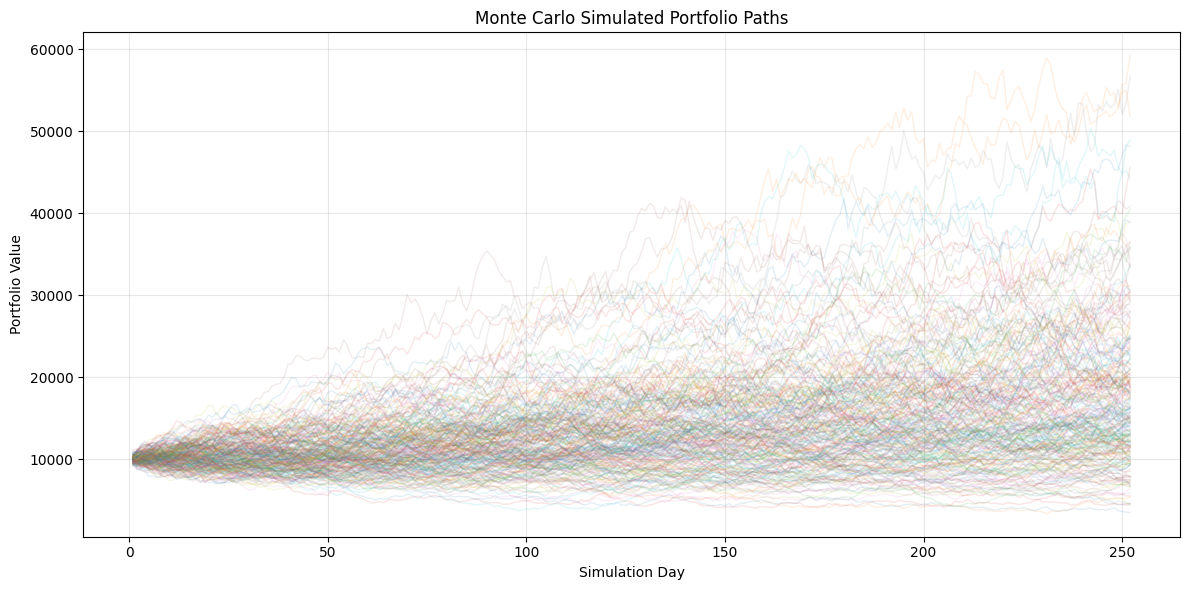

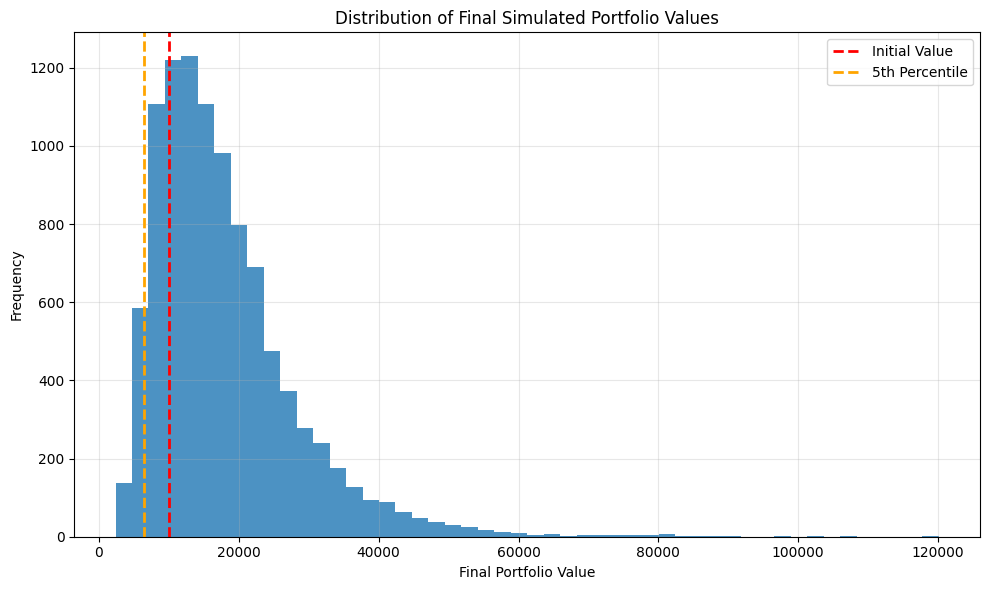

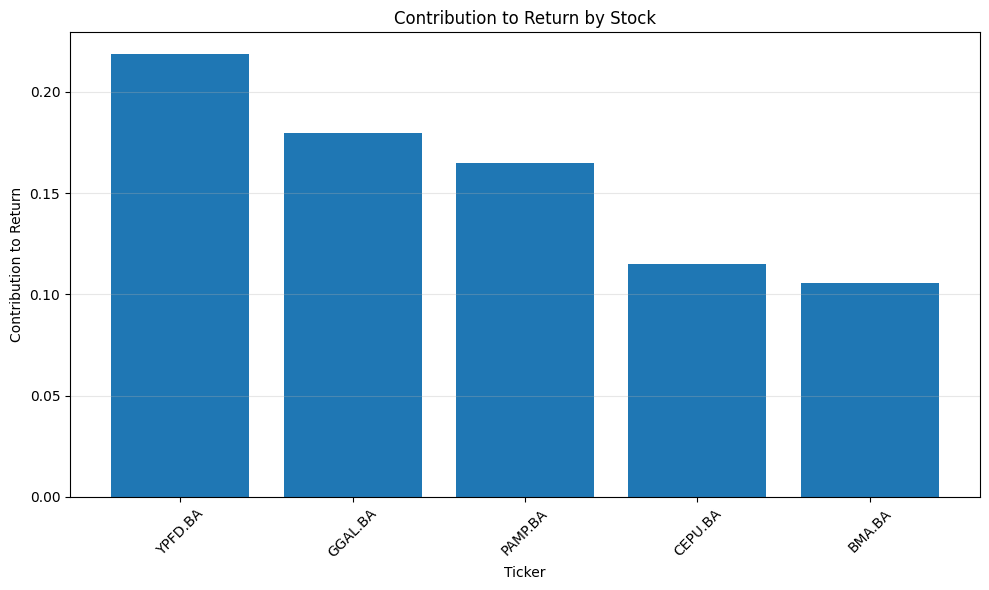

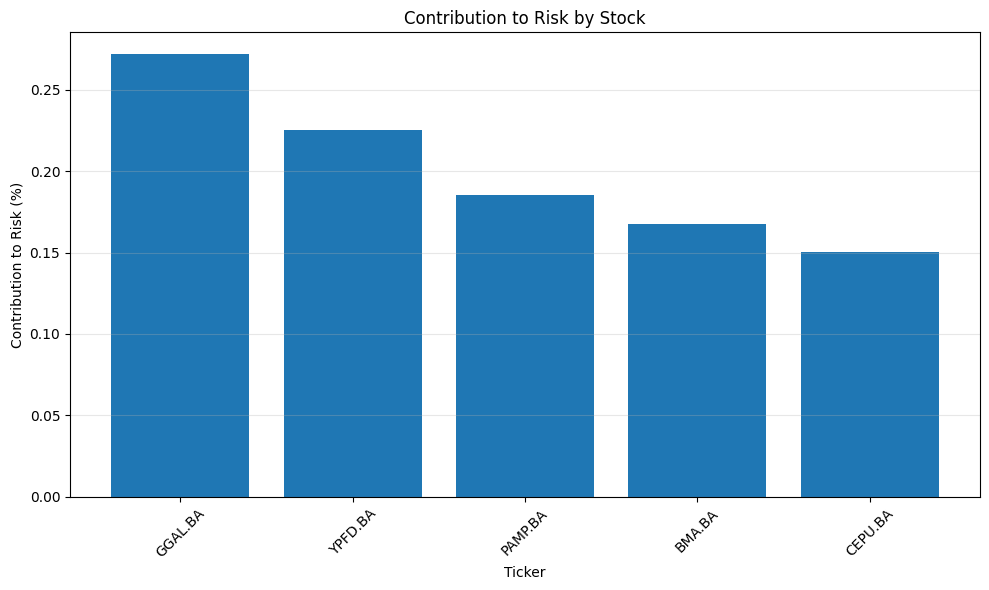

Charts saved to:
- outputs/charts/monte_carlo_paths.png
- outputs/charts/final_value_distribution.png
- outputs/charts/return_contribution.png
- outputs/charts/risk_contribution.png


In [15]:
output_dir = os.path.join("outputs", "charts")
os.makedirs(output_dir, exist_ok=True)

# 1. Simulated path subset for visualization.
plt.figure(figsize=(12, 6))
for sim_id, sim_df in monte_carlo_paths.groupby("simulation_id"):
    plt.plot(sim_df["day"], sim_df["portfolio_value"], alpha=0.12, linewidth=1)
plt.title("Monte Carlo Simulated Portfolio Paths")
plt.xlabel("Simulation Day")
plt.ylabel("Portfolio Value")
plt.grid(alpha=0.3)
paths_chart_path = os.path.join(output_dir, "monte_carlo_paths.png")
plt.tight_layout()
plt.savefig(paths_chart_path, dpi=150)
plt.show()

# 2. Histogram of final simulated values.
plt.figure(figsize=(10, 6))
plt.hist(final_values, bins=50, alpha=0.8)
plt.axvline(INITIAL_PORTFOLIO_VALUE, color="red", linestyle="--", linewidth=2, label="Initial Value")
plt.axvline(percentile_5, color="orange", linestyle="--", linewidth=2, label="5th Percentile")
plt.title("Distribution of Final Simulated Portfolio Values")
plt.xlabel("Final Portfolio Value")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
distribution_chart_path = os.path.join(output_dir, "final_value_distribution.png")
plt.tight_layout()
plt.savefig(distribution_chart_path, dpi=150)
plt.show()

# 3. Contribution to return by stock.
plot_return_contrib = portfolio_contributions.sort_values("contribution_to_return", ascending=False)
plt.figure(figsize=(10, 6))
plt.bar(plot_return_contrib["ticker"], plot_return_contrib["contribution_to_return"])
plt.title("Contribution to Return by Stock")
plt.xlabel("Ticker")
plt.ylabel("Contribution to Return")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
return_chart_path = os.path.join(output_dir, "return_contribution.png")
plt.tight_layout()
plt.savefig(return_chart_path, dpi=150)
plt.show()

# 4. Contribution to risk by stock.
plot_risk_contrib = portfolio_contributions.sort_values("contribution_to_risk_pct", ascending=False)
plt.figure(figsize=(10, 6))
plt.bar(plot_risk_contrib["ticker"], plot_risk_contrib["contribution_to_risk_pct"])
plt.title("Contribution to Risk by Stock")
plt.xlabel("Ticker")
plt.ylabel("Contribution to Risk (%)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
risk_chart_path = os.path.join(output_dir, "risk_contribution.png")
plt.tight_layout()
plt.savefig(risk_chart_path, dpi=150)
plt.show()

print("Charts saved to:")
print(f"- {paths_chart_path}")
print(f"- {distribution_chart_path}")
print(f"- {return_chart_path}")
print(f"- {risk_chart_path}")

# 12. Portfolio classification

This section assigns a simple rule-based portfolio type for interpretation.

## Example classification logic
- conservative: low volatility, low beta, low probability of loss
- balanced: moderate volatility and beta
- aggressive: high volatility or high beta
- high-risk FX-sensitive: high correlation with ARS/USD or signs of elevated downside exposure linked to currency sensitivity

The notebook also creates a `stock_rankings` table that ranks portfolio constituents using a simple composite score built from return, Sharpe ratio, volatility, beta, and drawdown characteristics.

In [16]:
# Helper lookup functions for processed metrics.
def choose_metric_column(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None

vol_col = choose_metric_column(stock_metrics, ["volatility", "annual_volatility"])
sharpe_col = choose_metric_column(stock_metrics, ["sharpe_ratio", "annual_sharpe", "sharpe"])
mdd_col = choose_metric_column(stock_metrics, ["max_drawdown", "drawdown"])
stock_return_col = choose_metric_column(stock_metrics, ["annual_return", "average_return", "expected_return", "return_annualized"])

corr_fx_col = choose_metric_column(correlation_matrix_long, ["correlation", "correlation_value"])

fx_sensitive = False
fx_reason = ""
if corr_fx_col and {"ticker_1", "ticker_2"}.issubset(correlation_matrix_long.columns):
    fx_pairs = correlation_matrix_long[
        (
            correlation_matrix_long["ticker_1"].isin(weights.index)
            & correlation_matrix_long["ticker_2"].astype(str).str.contains("USD|FX|ARS", case=False, na=False)
        )
        |
        (
            correlation_matrix_long["ticker_2"].isin(weights.index)
            & correlation_matrix_long["ticker_1"].astype(str).str.contains("USD|FX|ARS", case=False, na=False)
        )
    ].copy()
    if not fx_pairs.empty:
        max_abs_fx_corr = fx_pairs[corr_fx_col].abs().max()
        if pd.notna(max_abs_fx_corr) and max_abs_fx_corr >= 0.50:
            fx_sensitive = True
            fx_reason = f"High observed FX correlation ({max_abs_fx_corr:.2f})."

if fx_sensitive and probability_of_loss >= 0.35:
    portfolio_type = "high-risk FX-sensitive"
    portfolio_type_reason = f"Portfolio shows elevated downside risk and currency sensitivity. {fx_reason}".strip()
elif portfolio_volatility <= 0.20 and (pd.isna(weighted_beta_merval) or weighted_beta_merval <= 0.90) and probability_of_loss <= 0.25:
    portfolio_type = "conservative"
    portfolio_type_reason = "Low volatility, contained beta exposure, and relatively low probability of capital loss."
elif portfolio_volatility >= 0.35 or (pd.notna(weighted_beta_merval) and weighted_beta_merval >= 1.20):
    portfolio_type = "aggressive"
    portfolio_type_reason = "High volatility and/or elevated market beta indicate stronger upside-downside swings."
else:
    portfolio_type = "balanced"
    portfolio_type_reason = "Portfolio sits between defensive and aggressive thresholds on volatility and beta."

portfolio_scenarios["portfolio_type"] = portfolio_type
portfolio_scenarios["portfolio_type_reason"] = portfolio_type_reason

# Build stock-level ranking view.
stock_rank_base = stock_metrics.copy()
stock_rank_base["ticker"] = stock_rank_base["ticker"].astype(str)
stock_rank_base = stock_rank_base[stock_rank_base["ticker"].isin(weights.index)].copy()

if beta_merval_col and "ticker" in beta_metrics.columns:
    beta_for_ranking = beta_metrics[["ticker", beta_merval_col]].drop_duplicates(subset=["ticker"])
    stock_rank_base = stock_rank_base.merge(beta_for_ranking, on="ticker", how="left")
    stock_rank_base = stock_rank_base.rename(columns={beta_merval_col: "beta_vs_merval"})
else:
    stock_rank_base["beta_vs_merval"] = np.nan

if vol_col and vol_col != "volatility":
    stock_rank_base = stock_rank_base.rename(columns={vol_col: "volatility"})
if sharpe_col and sharpe_col != "sharpe_ratio":
    stock_rank_base = stock_rank_base.rename(columns={sharpe_col: "sharpe_ratio"})
if mdd_col and mdd_col != "max_drawdown":
    stock_rank_base = stock_rank_base.rename(columns={mdd_col: "max_drawdown"})
if stock_return_col and stock_return_col != "annual_return":
    stock_rank_base = stock_rank_base.rename(columns={stock_return_col: "annual_return"})

for col in ["annual_return", "volatility", "beta_vs_merval", "sharpe_ratio", "max_drawdown"]:
    if col not in stock_rank_base.columns:
        stock_rank_base[col] = np.nan

stock_rank_base["ranking_score"] = (
    stock_rank_base["annual_return"].fillna(0) * 0.35
    + stock_rank_base["sharpe_ratio"].fillna(0) * 0.35
    - stock_rank_base["volatility"].fillna(0) * 0.15
    - stock_rank_base["beta_vs_merval"].fillna(0) * 0.10
    + stock_rank_base["max_drawdown"].fillna(0) * 0.05
)

stock_rank_base["portfolio_type"] = portfolio_type
stock_rank_base["justification"] = stock_rank_base.apply(
    lambda row: (
        f"Sharpe={row['sharpe_ratio']:.2f}, Vol={row['volatility']:.2f}, "
        f"Beta={row['beta_vs_merval']:.2f}, MaxDD={row['max_drawdown']:.2f}"
        if pd.notna(row["sharpe_ratio"]) and pd.notna(row["volatility"]) else
        "Ranking based on available processed return and risk metrics."
    ),
    axis=1
)
stock_rank_base["run_id"] = RUN_ID
stock_rank_base["ingestion_timestamp"] = INGESTION_TIMESTAMP

stock_rankings = stock_rank_base[[
    "ticker",
    "portfolio_type",
    "ranking_score",
    "volatility",
    "beta_vs_merval",
    "sharpe_ratio",
    "max_drawdown",
    "justification",
    "run_id",
    "ingestion_timestamp",
]].sort_values("ranking_score", ascending=False).reset_index(drop=True)

portfolio_scenarios[["portfolio_id", "portfolio_type", "portfolio_type_reason"]]

,portfolio_id,portfolio_type,portfolio_type_reason
0,argentina_demo_portfolio,aggressive,High volatility and/or elevated market beta in...


# 13. Upload analytics tables to BigQuery

This section publishes the final analytics and serving outputs to the `analytics_market` dataset.

Write strategy:
- use `WRITE_APPEND` for run-based outputs that contain `run_id`
- use `WRITE_TRUNCATE` only for replaceable reference tables such as the data dictionary

If the dataset does not yet exist, create it in BigQuery before running this section.

In [17]:
#Would normally use WRITE_APPEND for evolving analytics tables, but using
# WRITE_TRUNCATE here for demo purposes to simplify repeated runs without
#  accumulating multiple scenario rows per run_id. + Costs money :\

analytics_uploads = [
    (portfolio_inputs, ANALYTICS_DATASET, "portfolio_inputs", "WRITE_TRUNCATE"),
    (portfolio_scenarios, ANALYTICS_DATASET, "portfolio_scenarios", "WRITE_TRUNCATE"),
    (portfolio_contributions, ANALYTICS_DATASET, "portfolio_contributions", "WRITE_TRUNCATE"),
    (monte_carlo_paths, ANALYTICS_DATASET, "monte_carlo_paths", "WRITE_TRUNCATE"),
    (monte_carlo_summary, ANALYTICS_DATASET, "monte_carlo_summary", "WRITE_TRUNCATE"),
    (stock_rankings, ANALYTICS_DATASET, "stock_rankings", "WRITE_TRUNCATE"),
]

written_tables = []
for df, dataset, table, disposition in analytics_uploads:
    load_dataframe_to_bq(df, dataset, table, write_disposition=disposition)
    written_tables.append(table_ref(dataset, table))
    print(f"Confirmed upload -> {table_ref(dataset, table)}")

Uploaded 5 rows to bigdata-financeargentina.analytics_market.portfolio_inputs with WRITE_TRUNCATE
Confirmed upload -> bigdata-financeargentina.analytics_market.portfolio_inputs
Uploaded 1 rows to bigdata-financeargentina.analytics_market.portfolio_scenarios with WRITE_TRUNCATE
Confirmed upload -> bigdata-financeargentina.analytics_market.portfolio_scenarios
Uploaded 5 rows to bigdata-financeargentina.analytics_market.portfolio_contributions with WRITE_TRUNCATE
Confirmed upload -> bigdata-financeargentina.analytics_market.portfolio_contributions
Uploaded 63,000 rows to bigdata-financeargentina.analytics_market.monte_carlo_paths with WRITE_TRUNCATE
Confirmed upload -> bigdata-financeargentina.analytics_market.monte_carlo_paths
Uploaded 1 rows to bigdata-financeargentina.analytics_market.monte_carlo_summary with WRITE_TRUNCATE
Confirmed upload -> bigdata-financeargentina.analytics_market.monte_carlo_summary
Uploaded 5 rows to bigdata-financeargentina.analytics_market.stock_rankings with W

# 14. Data dictionary generation

A serving layer is more useful when downstream users understand what each field means and how it was calculated.

This section creates a tidy data dictionary with:
- `table_name`
- `column_name`
- `data_type`
- `definition`
- `transformation_logic`
- `business_use`

The data dictionary is uploaded with `WRITE_TRUNCATE` because it is a replaceable documentation table rather than a run-history table.

In [18]:
data_dictionary_records = [
    {
        "table_name": "processed_market.asset_returns",
        "column_name": "log_return",
        "data_type": "FLOAT",
        "definition": "Natural log of daily price relative between consecutive observations.",
        "transformation_logic": "Calculated as LN(price_t / price_t-1) after sorting by ticker and date.",
        "business_use": "Core return metric for risk modeling, correlations, and simulation inputs."
    },
    {
        "table_name": "processed_market.asset_returns",
        "column_name": "usd_adjusted_return",
        "data_type": "FLOAT",
        "definition": "Daily stock return adjusted for ARS/USD currency movement.",
        "transformation_logic": "Combines local equity return with foreign-exchange return to estimate USD investor performance.",
        "business_use": "Used to evaluate exposure after currency devaluation effects."
    },
    {
        "table_name": "processed_market.asset_returns",
        "column_name": "excess_return",
        "data_type": "FLOAT",
        "definition": "Daily asset return minus daily risk-free rate.",
        "transformation_logic": "Return series less aligned risk-free daily series.",
        "business_use": "Supports Sharpe ratio and risk-adjusted performance analysis."
    },
    {
        "table_name": "processed_market.beta_metrics",
        "column_name": "beta_vs_merval",
        "data_type": "FLOAT",
        "definition": "Sensitivity of stock return to MERVAL market return.",
        "transformation_logic": "Estimated from covariance or regression between stock return and MERVAL return.",
        "business_use": "Measures local market systematic risk."
    },
    {
        "table_name": "processed_market.beta_metrics",
        "column_name": "beta_vs_eem",
        "data_type": "FLOAT",
        "definition": "Sensitivity of stock return to EEM return as an emerging markets proxy.",
        "transformation_logic": "Estimated from covariance or regression between stock return and EEM return.",
        "business_use": "Adds an external benchmark for international risk context."
    },
    {
        "table_name": "processed_market.stock_metrics",
        "column_name": "volatility",
        "data_type": "FLOAT",
        "definition": "Annualized standard deviation of daily returns.",
        "transformation_logic": "STDDEV(daily_return) multiplied by sqrt(252).",
        "business_use": "Primary standalone risk metric for ranking and classification."
    },
    {
        "table_name": "processed_market.stock_metrics",
        "column_name": "sharpe_ratio",
        "data_type": "FLOAT",
        "definition": "Risk-adjusted return relative to risk-free rate.",
        "transformation_logic": "Annualized excess return divided by annualized volatility.",
        "business_use": "Helps compare return quality across securities and portfolios."
    },
    {
        "table_name": "processed_market.stock_metrics",
        "column_name": "max_drawdown",
        "data_type": "FLOAT",
        "definition": "Largest peak-to-trough cumulative loss over the observation window.",
        "transformation_logic": "Computed from cumulative return path versus running peak.",
        "business_use": "Measures downside severity and investor pain during stress periods."
    },
    {
        "table_name": "processed_market.stock_metrics",
        "column_name": "inflation_proxy",
        "data_type": "FLOAT",
        "definition": "Average daily ARS/USD return acting as proxy for imported inflation in Argentina.",
        "transformation_logic": "Mean of daily USDARS returns; higher values indicate greater inflation pressure.",
        "business_use": "Used to assess currency-driven inflation exposure in Argentine equities."
    },
    {
        "table_name": "processed_market.stock_metrics",
        "column_name": "country_risk_proxy",
        "data_type": "FLOAT",
        "definition": "Average daily VIX level acting as proxy for emerging market risk sentiment.",
        "transformation_logic": "Mean of daily VIX values; higher values indicate elevated country risk premium.",
        "business_use": "Used to assess overall market risk sentiment exposure."
    },
    {
        "table_name": "processed_market.stock_metrics",
        "column_name": "sortino_ratio",
        "data_type": "FLOAT",
        "definition": "Risk-adjusted return using downside deviation instead of total volatility.",
        "transformation_logic": "(Annual Return - Risk Free Rate) / Downside Deviation. Only penalizes negative returns.",
        "business_use": "Better than Sharpe for asymmetric return distributions; measures return per unit of downside risk."
    },
    {
        "table_name": "processed_market.stock_metrics",
        "column_name": "calmar_ratio",
        "data_type": "FLOAT",
        "definition": "Return per unit of maximum drawdown (return/maxDD).",
        "transformation_logic": "Annual Return / Absolute Max Drawdown. Higher is better.",
        "business_use": "Critical for emerging markets; measures how quickly portfolio recovers from worst-case loss."
    },
    {
        "table_name": "analytics_market.portfolio_contributions",
        "column_name": "fx_correlation",
        "data_type": "FLOAT",
        "definition": "Correlation between stock returns and USDARS ( peso-dollar ) exchange rate changes.",
        "transformation_logic": "Pearson correlation from aligned daily return pairs.",
        "business_use": "High positive correlation = stock benefits from ARS depreciation; high negative = currency headwind."
    },
    {
        "table_name": "analytics_market.portfolio_contributions",
        "column_name": "inflation_exposure",
        "data_type": "FLOAT",
        "definition": "Average daily USDARS return while holding this stock (proxy for imported inflation).",
        "transformation_logic": "Mean of daily USDARS returns weighted by exposure period.",
        "business_use": "Measures currency-driven inflation pressure on portfolio."
    },
    {
        "table_name": "analytics_market.portfolio_contributions",
        "column_name": "country_risk_exposure",
        "data_type": "FLOAT",
        "definition": "Average daily VIX level while holding this stock (proxy for emerging market risk).",
        "transformation_logic": "Mean of daily VIX values during holding period.",
        "business_use": "Measures overall market risk sentiment exposure."
    },
    {
        "table_name": "analytics_market.portfolio_contributions",
        "column_name": "currency_risk_score",
        "data_type": "FLOAT",
        "definition": "Combined currency risk metric accounting for FX correlation and macro exposures.",
        "transformation_logic": "abs(fx_correlation) * (1 + inflation_exposure) * (1 + country_risk_exposure).",
        "business_use": "Single metric to rank stocks by overall currency risk in Argentine context."
    },
    {
        "table_name": "processed_market.correlation_matrix_long",
        "column_name": "correlation",
        "data_type": "FLOAT",
        "definition": "Pairwise linear correlation between two return series.",
        "transformation_logic": "Calculated from aligned daily return pairs and stored in long form.",
        "business_use": "Used for diversification analysis and FX sensitivity checks."
    },
    {
        "table_name": "analytics_market.portfolio_scenarios",
        "column_name": "portfolio_volatility",
        "data_type": "FLOAT",
        "definition": "Annualized volatility of the weighted portfolio return series.",
        "transformation_logic": "Portfolio daily standard deviation multiplied by sqrt(252).",
        "business_use": "Used in portfolio classification and investor suitability analysis."
    },
    {
        "table_name": "analytics_market.portfolio_scenarios",
        "column_name": "diversification_effect",
        "data_type": "FLOAT",
        "definition": "Difference between weighted average asset volatility and portfolio volatility.",
        "transformation_logic": "Weighted average constituent volatility minus actual portfolio volatility.",
        "business_use": "Shows how much total risk is reduced by diversification."
    },
    {
        "table_name": "analytics_market.portfolio_scenarios",
        "column_name": "concentration_risk_hhi",
        "data_type": "FLOAT",
        "definition": "Herfindahl-Hirschman Index of portfolio weights.",
        "transformation_logic": "Sum of squared weights.",
        "business_use": "Measures concentration risk and weight dispersion."
    },
    {
        "table_name": "analytics_market.monte_carlo_summary",
        "column_name": "probability_of_loss",
        "data_type": "FLOAT",
        "definition": "Share of simulations ending below the initial portfolio value.",
        "transformation_logic": "COUNT(final_value < initial_value) / num_simulations.",
        "business_use": "Simple downside-risk indicator for decision support."
    },
    {
        "table_name": "analytics_market.monte_carlo_summary",
        "column_name": "var_95",
        "data_type": "FLOAT",
        "definition": "95% Value at Risk measured from the 5th percentile of final simulated values.",
        "transformation_logic": "Initial portfolio value minus the 5th percentile final value.",
        "business_use": "Estimates a downside threshold under stressed but non-tail simulation outcomes."
    },
    {
        "table_name": "analytics_market.monte_carlo_summary",
        "column_name": "cvar_95",
        "data_type": "FLOAT",
        "definition": "95% Conditional Value at Risk using the average of the worst 5% outcomes.",
        "transformation_logic": "Initial value minus mean(final values in worst 5% tail).",
        "business_use": "Captures expected loss severity beyond the VaR cutoff."
    },
    {
        "table_name": "analytics_market.monte_carlo_summary",
        "column_name": "monte_carlo_percentiles",
        "data_type": "STRUCT-LIKE CONCEPT",
        "definition": "Percentile-based summary of final simulated outcomes.",
        "transformation_logic": "Represented through percentile_5, percentile_25, percentile_75, and percentile_95 columns.",
        "business_use": "Provides intuitive upside/downside scenario bands for reports and dashboards."
    },
]

data_dictionary = pd.DataFrame(data_dictionary_records)
data_dictionary["run_id"] = RUN_ID
data_dictionary["ingestion_timestamp"] = INGESTION_TIMESTAMP

load_dataframe_to_bq(
    data_dictionary,
    ANALYTICS_DATASET,
    "data_dictionary",
    write_disposition="WRITE_TRUNCATE"
)
print(f"Confirmed upload -> {table_ref(ANALYTICS_DATASET, 'data_dictionary')}")

Uploaded 24 rows to bigdata-financeargentina.analytics_market.data_dictionary with WRITE_TRUNCATE
Confirmed upload -> bigdata-financeargentina.analytics_market.data_dictionary


# 15. dbt integration section

## Why dbt belongs in this project
- dbt controls transformations from raw to processed and analytics layers.
- dbt models make lineage visible across warehouse objects.
- dbt tests improve reliability by catching missing keys, nulls, and relationship issues early.
- dbt docs generate browsable documentation for submission and stakeholder communication.
- dbt connects to BigQuery through a local `profiles.yml` configuration.

## Example dbt workflow
The commands below are examples and are intentionally shown as documentation. They do not need to be executed inside this notebook.

```bash
dbt debug
dbt run
dbt test
dbt docs generate
dbt docs serve
```

## Example model: `models/staging/stg_asset_returns.sql`
Purpose:
- clean date, ticker, and return columns
- remove null returns

```sql
with source_data as (
    select *
    from {{ source('raw_market', 'stock_prices') }}
), cleaned as (
    select
        cast(date as date) as date,
        cast(ticker as string) as ticker,
        cast(close as float64) as close,
        lag(cast(close as float64)) over (partition by ticker order by cast(date as date)) as prev_close
    from source_data
    where close is not null
)
select
    date,
    ticker,
    close,
    safe_divide(close, prev_close) - 1 as simple_return,
    case
        when prev_close is null or prev_close = 0 then null
        else ln(close / prev_close)
    end as log_return
from cleaned
where prev_close is not null
  and close is not null
```

## Example model: `models/intermediate/int_portfolio_metrics.sql`
Purpose:
- aggregate user portfolio results

```sql
with asset_returns as (
    select * from {{ ref('stg_asset_returns') }}
), selected as (
    select *
    from asset_returns
    where ticker in ('GGAL.BA', 'YPFD.BA', 'PAMP.BA', 'BMA.BA', 'CEPU.BA')
), weighted as (
    select
        date,
        sum(
            case ticker
                when 'GGAL.BA' then log_return * 0.25
                when 'YPFD.BA' then log_return * 0.25
                when 'PAMP.BA' then log_return * 0.20
                when 'BMA.BA' then log_return * 0.15
                when 'CEPU.BA' then log_return * 0.15
                else 0
            end
        ) as portfolio_return
    from selected
    group by date
)
select
    date,
    portfolio_return,
    avg(portfolio_return) over() * 252 as expected_portfolio_return,
    stddev(portfolio_return) over() * sqrt(252) as portfolio_volatility
from weighted
```

## Example model: `models/marts/mart_monte_carlo_summary.sql`
Purpose:
- final serving table for dashboard/report

```sql
select
    portfolio_id,
    run_id,
    initial_value,
    num_simulations,
    simulation_days,
    mean_final_value,
    median_final_value,
    min_final_value,
    max_final_value,
    percentile_5,
    percentile_25,
    percentile_75,
    percentile_95,
    probability_of_loss,
    expected_return_simulated,
    var_95,
    cvar_95,
    ingestion_timestamp
from {{ source('analytics_market', 'monte_carlo_summary') }}
```

## Example `models/schema.yml`
Includes tests:
- `not_null` on `portfolio_id`
- `not_null` on `ticker`
- `not_null` on `date`
- accepted range tests where sensible
- relationship tests where sensible

```yaml
version: 2

models:
  - name: stg_asset_returns
    description: Cleaned daily asset return model.
    columns:
      - name: date
        tests:
          - not_null
      - name: ticker
        tests:
          - not_null
      - name: log_return
        tests:
          - not_null

  - name: int_portfolio_metrics
    description: Aggregated weighted portfolio return model.
    columns:
      - name: date
        tests:
          - not_null
      - name: portfolio_return
        tests:
          - not_null

  - name: mart_monte_carlo_summary
    description: Serving-layer summary for Monte Carlo simulation outputs.
    columns:
      - name: portfolio_id
        tests:
          - not_null
      - name: probability_of_loss
        tests:
          - dbt_utils.accepted_range:
              min_value: 0
              max_value: 1
      - name: var_95
        tests:
          - not_null
      - name: cvar_95
        tests:
          - not_null

sources:
  - name: analytics_market
    tables:
      - name: monte_carlo_summary
        columns:
          - name: portfolio_id
            tests:
              - not_null
          - name: run_id
            tests:
              - not_null

  - name: processed_market
    tables:
      - name: asset_returns
        columns:
          - name: ticker
            tests:
              - relationships:
                  to: ref('stg_asset_returns')
                  field: ticker
```

# 16. Lineage diagram output

The Mermaid diagram below summarizes how raw inputs feed processed models and then power analytics and serving-layer outputs.

```mermaid
flowchart LR
    A[raw_market.stock_prices] --> B[processed_market.asset_returns]
    C[raw_market.fx_prices] --> D[processed_market.factor_returns]
    E[raw_market.merval_prices] --> D
    F[raw_market.eem_prices] --> D
    G[raw_market.rf_rates] --> D
    B --> H[processed_market.stock_metrics]
    D --> I[processed_market.beta_metrics]
    B --> J[analytics_market.portfolio_scenarios]
    H --> J
    I --> J
    J --> K[analytics_market.monte_carlo_summary]
    J --> L[Dashboard or Report]
    K --> L
```

# 17. Final summary cell

The final code cell prints a concise summary of the generated portfolio analytics outputs and the BigQuery tables written during the run.

In [19]:
summary_row = monte_carlo_summary.iloc[0]
scenario_row = portfolio_scenarios.iloc[0]

print("=" * 80)
print("Argentina Portfolio Risk Intelligence Pipeline - Final Summary")
print("=" * 80)
print(f"Portfolio ID: {PORTFOLIO_ID}")
print(f"Expected annual return: {scenario_row['expected_portfolio_return']:.4f}")
print(f"Annual volatility: {scenario_row['portfolio_volatility']:.4f}")
print(f"Sharpe ratio: {scenario_row['weighted_sharpe']:.4f}")
print(f"Weighted beta: {scenario_row['weighted_beta_merval']:.4f}")
print(f"Probability of loss: {summary_row['probability_of_loss']:.4f}")
print(f"VaR 95: {summary_row['var_95']:.2f}")
print(f"CVaR 95: {summary_row['cvar_95']:.2f}")
print(f"Portfolio classification: {scenario_row['portfolio_type']}")
print(f"Classification reason: {scenario_row['portfolio_type_reason']}")
print("BigQuery tables written:")
for table_name in written_tables + [table_ref(ANALYTICS_DATASET, 'data_dictionary')]:
    print(f"- {table_name}")
print("=" * 80)

Argentina Portfolio Risk Intelligence Pipeline - Final Summary
Portfolio ID: argentina_demo_portfolio
Expected annual return: 0.7820
Annual volatility: 0.5369
Sharpe ratio: 1.0243
Weighted beta: 1.0983
Probability of loss: 0.2092
VaR 95: 3595.09
CVaR 95: 4777.77
Portfolio classification: aggressive
Classification reason: High volatility and/or elevated market beta indicate stronger upside-downside swings.
BigQuery tables written:
- bigdata-financeargentina.analytics_market.portfolio_inputs
- bigdata-financeargentina.analytics_market.portfolio_scenarios
- bigdata-financeargentina.analytics_market.portfolio_contributions
- bigdata-financeargentina.analytics_market.monte_carlo_paths
- bigdata-financeargentina.analytics_market.monte_carlo_summary
- bigdata-financeargentina.analytics_market.stock_rankings
- bigdata-financeargentina.analytics_market.data_dictionary
